loading the cleaned dataset

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("C:/Users/Asus/OneDrive/Documents/ml project datasets/customer churn/telecom_customer_churn.csv")

# creating the target column
df["churn"] = df["Customer Status"].apply(lambda x: 1 if x == "Churned" else 0)

In [16]:
df.shape # = (7043,38)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

MISSING VALUES ANALYSIS

In [17]:
ms = df.isnull().sum().sort_values(ascending=False)
print(ms)

Churn Reason                         5174
Churn Category                       5174
Offer                                3877
Streaming TV                         1526
Device Protection Plan               1526
Online Security                      1526
Online Backup                        1526
Streaming Music                      1526
Streaming Movies                     1526
Avg Monthly GB Download              1526
Unlimited Data                       1526
Internet Type                        1526
Premium Tech Support                 1526
Multiple Lines                        682
Avg Monthly Long Distance Charges     682
Zip Code                                0
City                                    0
Number of Dependents                    0
Married                                 0
Age                                     0
Gender                                  0
Customer ID                             0
Phone Service                           0
Internet Service                  

In [18]:
missing_precent = (df.isnull().sum() / len(df)) * 100
missing_precent.sort_values(ascending=False)


Churn Reason                         73.463013
Churn Category                       73.463013
Offer                                55.047565
Streaming TV                         21.666903
Device Protection Plan               21.666903
Online Security                      21.666903
Online Backup                        21.666903
Streaming Music                      21.666903
Streaming Movies                     21.666903
Avg Monthly GB Download              21.666903
Unlimited Data                       21.666903
Internet Type                        21.666903
Premium Tech Support                 21.666903
Multiple Lines                        9.683374
Avg Monthly Long Distance Charges     9.683374
Zip Code                              0.000000
City                                  0.000000
Number of Dependents                  0.000000
Married                               0.000000
Age                                   0.000000
Gender                                0.000000
Customer ID  

In [19]:
df['churn'].value_counts()
df['churn'].value_counts(normalize=True)*100

churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

In [20]:
pd.crosstab(df['Gender'], df['churn'],normalize="index")*100

churn,0,1
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [21]:
pd.crosstab(df['Contract'], df['churn'],normalize="index")*100

churn,0,1
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


In [22]:
pd.crosstab(df['Internet Service'], df['churn'],normalize="index")*100

churn,0,1
Internet Service,,
No,92.595020,7.404980
Yes,68.171107,31.828893


In [23]:
df.groupby("churn")["Monthly Charge"].mean()


churn
0    60.073618
1    73.347592
Name: Monthly Charge, dtype: float64

In [24]:
df.groupby("churn")["Tenure in Months"].mean()

churn
0    37.591225
1    17.979133
Name: Tenure in Months, dtype: float64

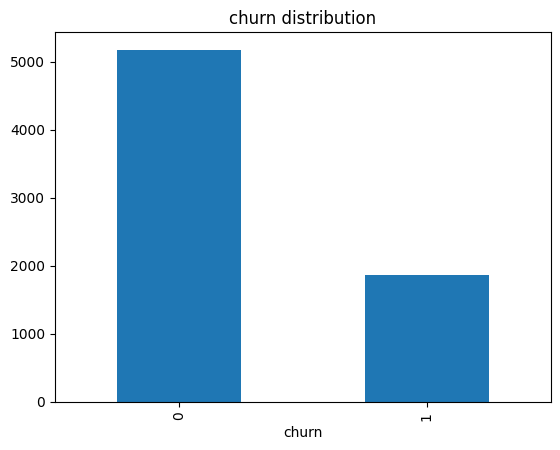

In [25]:
df["churn"].value_counts().plot(kind = 'bar')
plt.title("churn distribution")
plt.show()

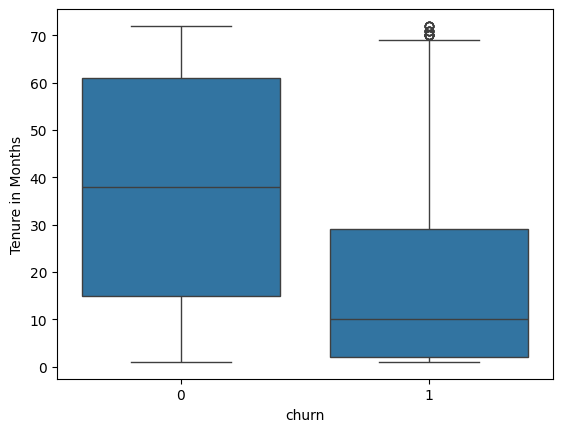

In [26]:
sns.boxplot(x="churn", y="Tenure in Months", data=df)
plt.show()